# NCAA forecasting | scored research progression
**Alvaro Mendizabal · employer-facing ML engineering case study**

The current post-competition release scored **0.1089408 Brier**, numerically below the published 2026 winning benchmark of **0.1097454**. This is benchmark-informed late research, not an original competition placement. The notebook renders approved aggregate evidence only; it cannot reproduce the private forecasting system.

In [1]:
from pathlib import Path
import sys
root=Path.cwd()
if not (root/'portfolio').is_dir(): root=root.parent
sys.path.insert(0,str(root/'portfolio'))
from current_research import load,chart
import pandas as pd
from IPython.display import display
d=load();s=d['scored'];i=d['integrity'];dc=d['decomposition']
display(pd.DataFrame([{'Release':'Margin ensemble','Brier':s['margin_release']['score']},{'Release':'Full market overlay','Brier':s['full_market']['score']},{'Release':'Round-1-only overlay','Brier':s['r1_market']['score']},{'Release':'Retained futures release','Brier':s['champion']['score']}]))

,Release,Brier
0,Margin ensemble,0.109490
1,Full market overlay,0.109804
2,Round-1-only overlay,0.110353
3,Retained futures release,0.108941


## 1. Recorded score progression
The retained release improves the preceding margin ensemble by **0.0005491 Brier** and is **0.0008046** numerically below the published winning benchmark. The broad market and Round-1 variants both lost, so the research record includes those negative results rather than only the successful submission.

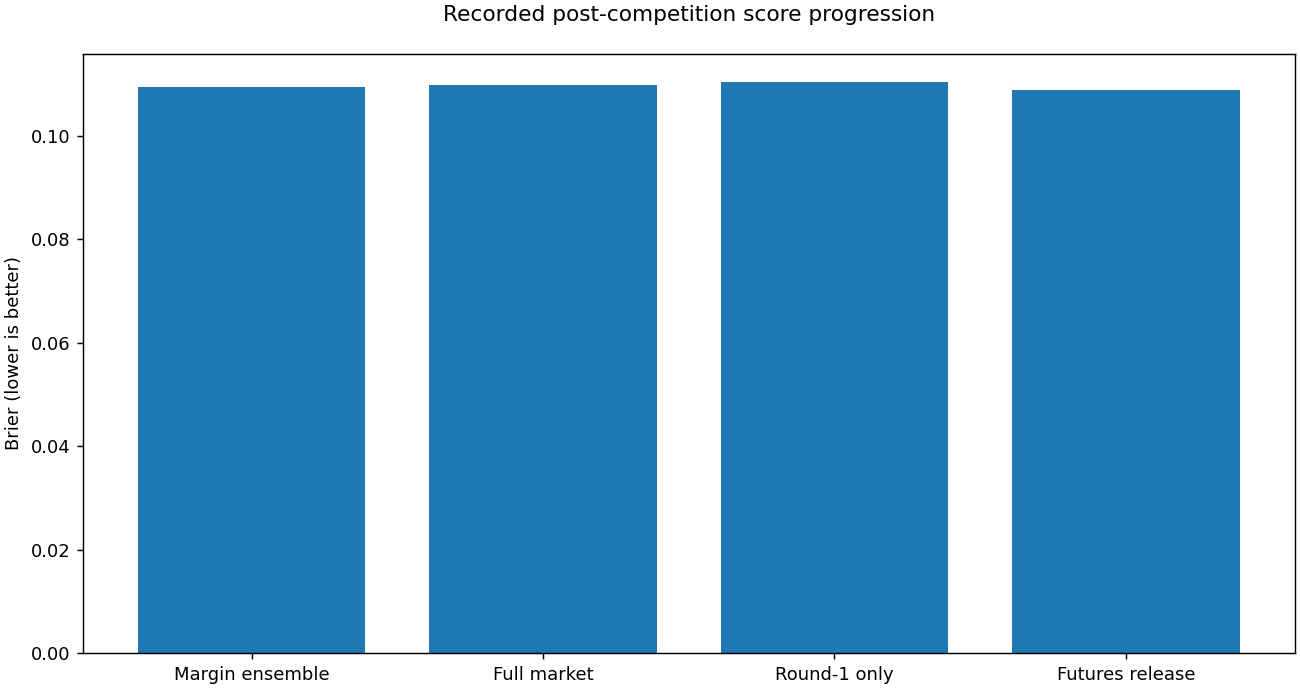

In [2]:
chart('release_scores','Recorded post-competition score progression',['Margin ensemble','Full market','Round-1 only','Futures release'],{'Brier':[s['margin_release']['score'],s['full_market']['score'],s['r1_market']['score'],s['champion']['score']]},'Brier (lower is better)')

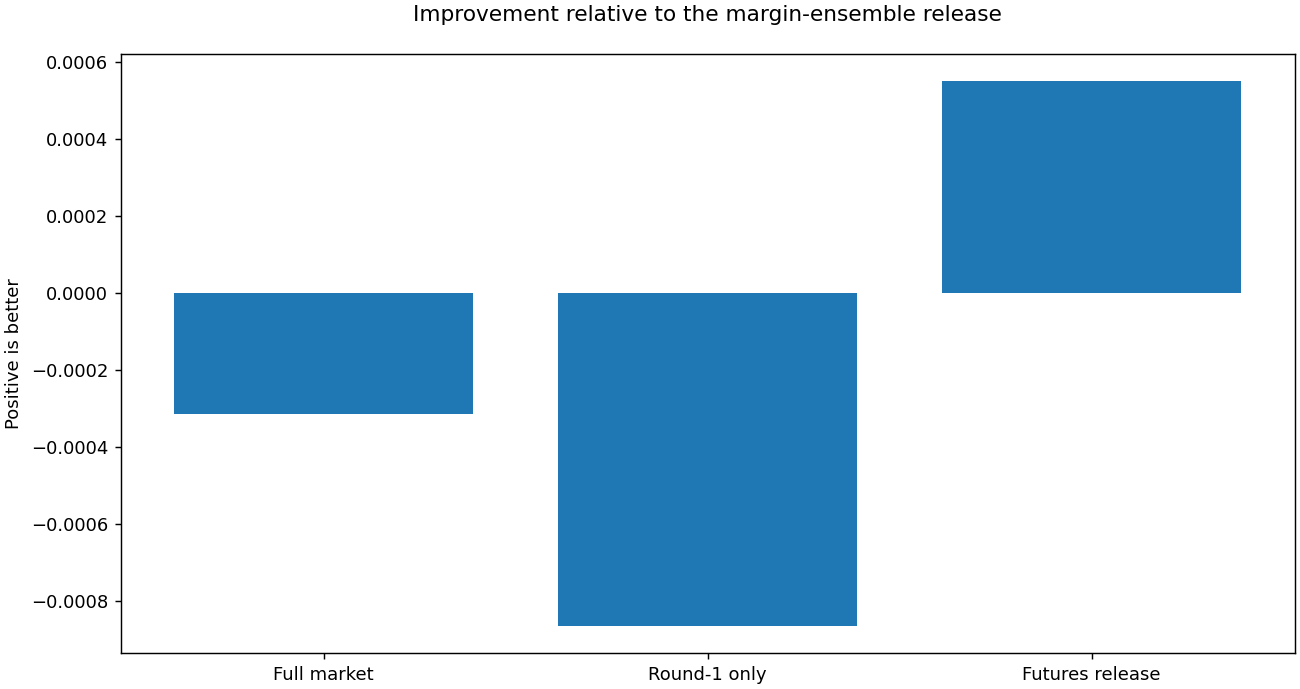

In [3]:
chart('gains','Improvement relative to the margin-ensemble release',['Full market','Round-1 only','Futures release'],{'Brier reduction':[s['margin_release']['score']-s['full_market']['score'],s['margin_release']['score']-s['r1_market']['score'],s['margin_release']['score']-s['champion']['score']]},'Positive is better')

## 2. Why the futures component could be isolated
The full market and Round-1-only files changed disjoint components. The 32 Round-1 predictions were identical across both variants. Removing that component from the full overlay therefore isolates the remaining 1,986-row championship-strength layer. The resulting implied interval contained the later scored value. This is strong arithmetic consistency, but the component choice is still post-hoc because two late scores informed the decision.

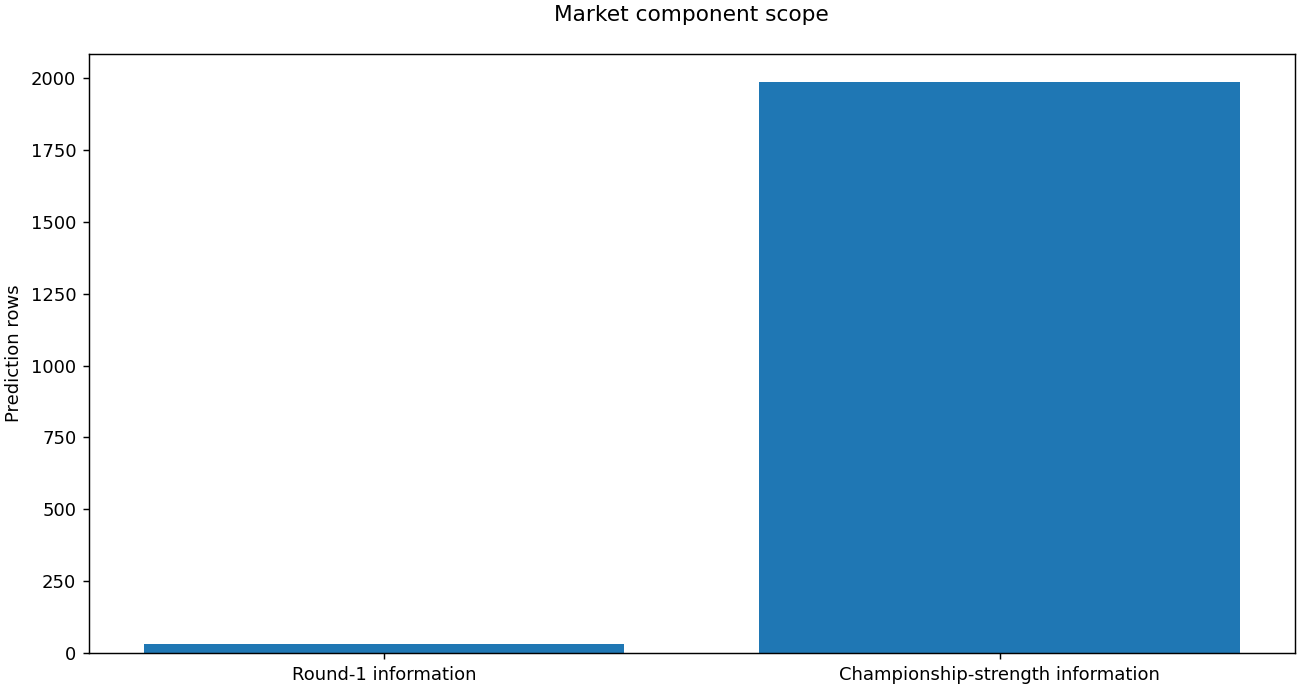

Implied score: 0.1089409
Observed futures-only score: 0.1089408


In [4]:
chart('market_components','Market component scope',['Round-1 information','Championship-strength information'],{'Rows changed':[dc['r1_rows'],dc['futures_rows']]},'Prediction rows')
print('Implied score:',dc['inferred_score'])
print('Observed futures-only score:',s['champion']['score'])

## 3. Engineering protected the existing system
The final score test changed only the isolated men’s component. All other predictions were copied exactly from the preceding champion, and the prior scored artifact was never overwritten. The run performed zero model fits and made exactly one upload.

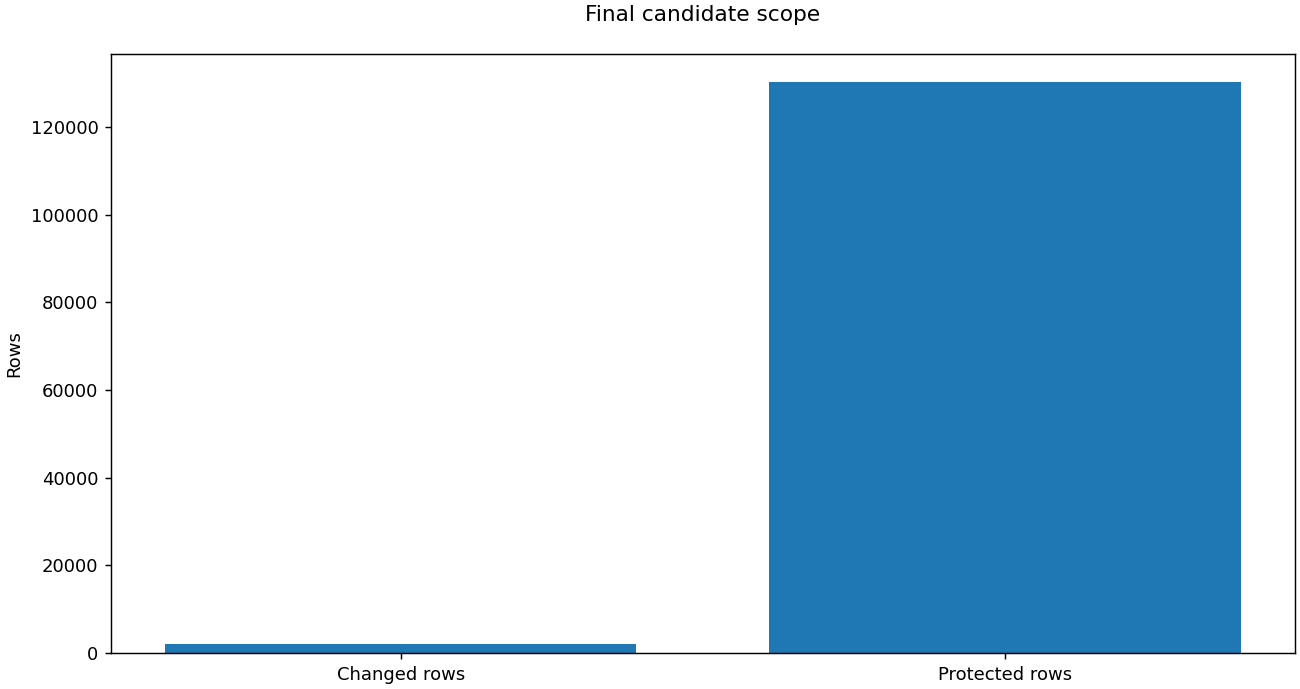

,rows,changed_rows,protected_rows,women_rows_unchanged,men_rows_unchanged,tree_fits,probability_model_fits,upload_attempts,automatic_followups,elapsed_seconds
0,132133,1986,130147,65703,64444,0,0,1,0,30.66


In [5]:
chart('scope','Final candidate scope',['Changed rows','Protected rows'],{'CSV rows':[i['changed_rows'],i['protected_rows']]},'Rows')
display(pd.DataFrame([i]))

## 4. Competitive context
The official winner scored 0.1097454. The retained late score is lower, but it came after the competition and after public solution information was available. The correct portfolio claim is an improved **post-competition benchmark**, not an original rank, medal, or prize.

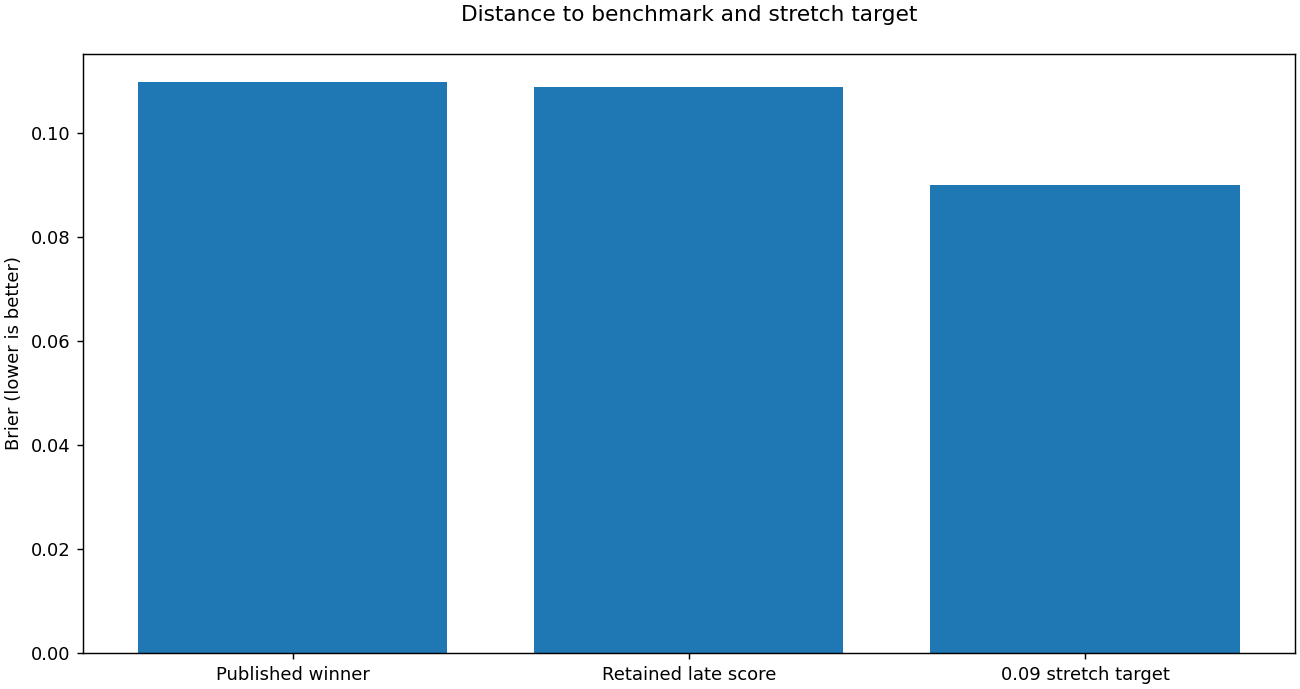

In [6]:
chart('score_gap','Distance to benchmark and stretch target',['Published winner','Retained late score','0.09 stretch target'],{'Brier':[s['benchmark'],s['champion']['score'],s['stretch_target']]},'Brier (lower is better)')

## 5. What changed technically
The strongest scored system combines a compact tournament reference, a complementary score-margin ensemble, and a bounded championship-strength information layer. The public case study communicates those capabilities and the decision process without distributing the current private training or inference implementation.

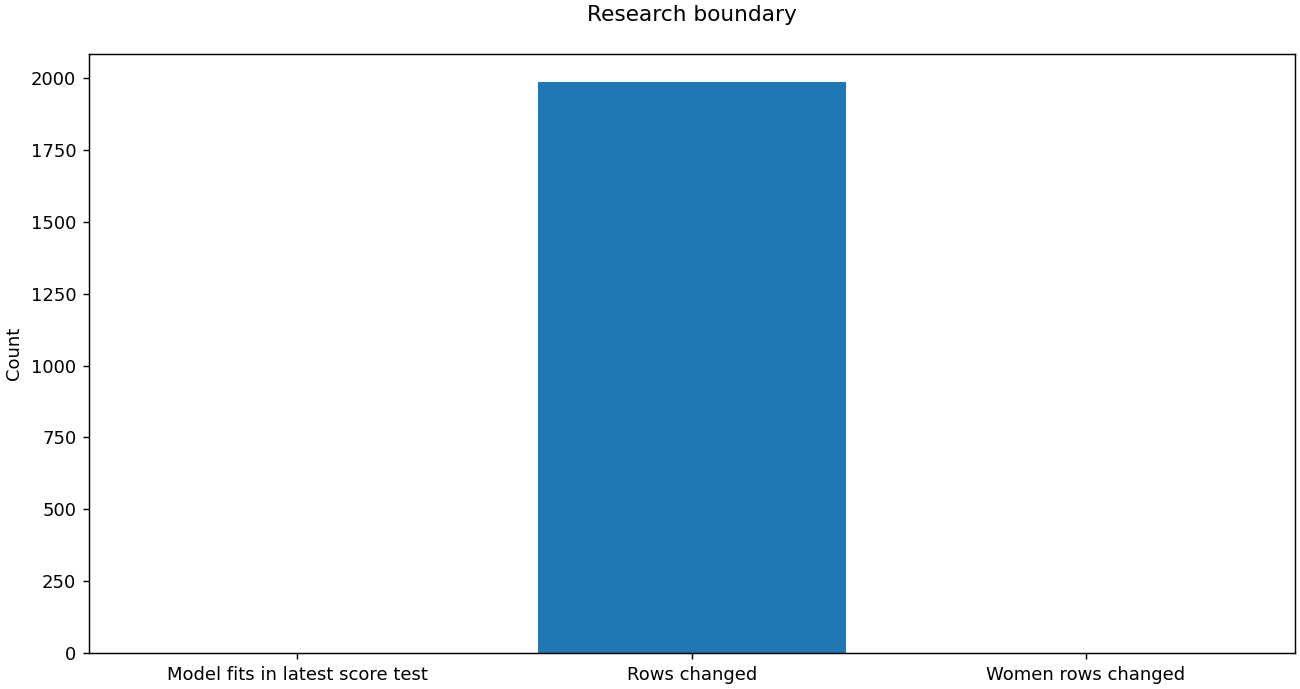

In [7]:
chart('research_boundary','Research boundary',['Model fits in latest score test','Rows changed','Women rows changed'],{'Count':[i['tree_fits']+i['probability_model_fits'],i['changed_rows'],0]},'Count')

## 6. Limitations and 2027
The 2026 late-submission loop is development research on a completed event. Multiple hypotheses and scored variants were explored, so this result is not independent confirmation. The next stronger generalization claim should come from a frozen 2027 process with timestamped inputs and predictions recorded before outcomes. Existing public history and licenses remain; new private implementation details are intentionally excluded from this release.

In [8]:
print('Retained submission:',s['champion']['ref'])
print('Retained Brier:',s['champion']['score'])
print('Model fits performed by this report:',0)
print('REPORT_COMPLETE — aggregate evidence only; no training or submission')

Retained submission: 56479241
Retained Brier: 0.1089408
Model fits performed by this report: 0
REPORT_COMPLETE — aggregate evidence only; no training or submission
